# Part 1 - Task 3: Data Exploration

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
df = pd.read_csv('../data/processed/news_sample_cleaned.csv', low_memory=False)

print(f"Shape: {df.shape}")
print("\nColumns and dtypes:")
print(df.dtypes)

Shape: (238, 14)

Columns and dtypes:
id                    int64
domain                  str
type                  int64
url                     str
content                 str
scraped_at              str
title                   str
authors                 str
meta_keywords           str
meta_description        str
tags                    str
content_normalized      str
title_normalized        str
content_processed       str
dtype: object


We load the processed dataset produced by the preprocessing pipeline. The DataFrame contains one row per article, with columns for the raw and processed text, metadata, and a binary label (0 = reliable, 1 = fake).

## Observation 1: label Distribution
We examine the balance between reliable (0) and fake (1) articles in the dataset.

Label distribution:
  fake: 212 (89.1%
  reliable: 26 (10.9%


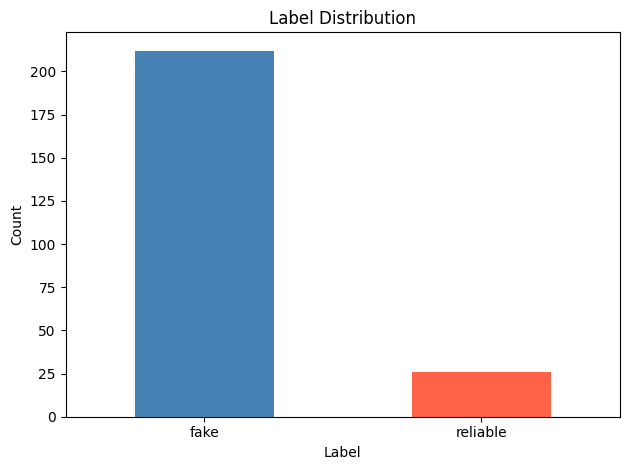

In [4]:
# Part 1.3 - Label distribution
label_counts = df['type'].value_counts()
label_names = {0: 'reliable', 1: 'fake'}

print("Label distribution:")
for label, count in label_counts.items():
    print(f"  {label_names[label]}: {count} ({count/len(df)*100:.1f}%")


label_counts.rename(index=label_names).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/labels_distribution.png')
plt.show()

## Observation 2: Article Length Distribution per Label
We compare the length of articles across reliable and fake labels.

reliable: mean=359, median=233, min=12, max=1707
fake: mean=402, median=286, min=9, max=3820


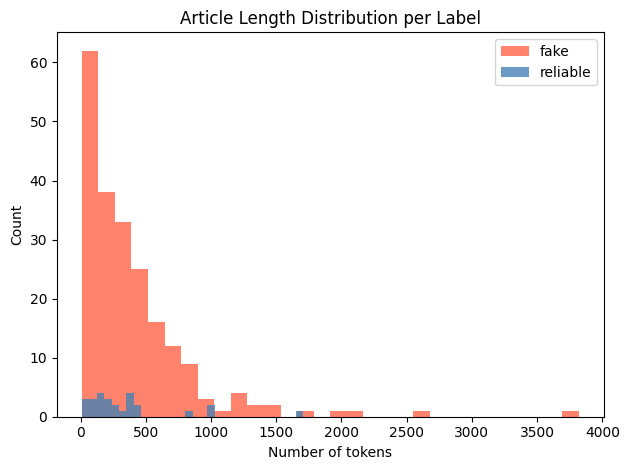

In [9]:
# Part 1.3 - Article length distribution per label
df['content_length'] = df['content_processed'].str.split().str.len()

for label, name in {0: 'reliable', 1: 'fake'}.items():
    subset = df[df['type'] == label]['content_length']
    print(f"{name}: mean={subset.mean():.0f}, median={subset.median():.0f}, min={subset.min():.0f}, max={subset.max()}")

fig, ax = plt.subplots()
for label, name, color in [(1, 'fake', 'tomato'), (0, 'reliable', 'steelblue')]:
    df[df['type'] == label]['content_length'].plot(kind='hist', bins=30, alpha=0.8, label=name, color=color, ax=ax)

ax.set_title('Article Length Distribution per Label')
ax.set_xlabel('Number of tokens')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/article_length_distribution.png')
plt.show()